In [1]:
# Adam Levonian
# Week 8 Assignment: Bootstrapping

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Week 8 Assignment: Bootstrapping

### 0. Data Cleaning and Exploratory Data Analysis

#### The Data

2,421 survey responses from Washington State Employees Credit Union (WSECU) members. Each row represents one member. 
- **Demographics:** `age`, `gender`, `region`, `public.sector`  
- **Institution Relationship:** `engagement`, `account.age`, `channel`  
- **Values:** `harm`, `fair`, `in.group`, `authority`, `purity`  
- **Institutional Priorities:** `localism`, `sustainability`  
- **Outcomes:**  
  - `main.focal.value` — The respondent’s chosen top cause or area of concern.  
  - `support.of.focal.value` — Level of support for that focal cause.

In [2]:
survey = pd.read_csv("../data/wsecu_survey_data.txt", sep="\t", index_col=0)

In [3]:
overview = pd.DataFrame({"dtype": survey.dtypes})
overview["count_null"] = survey.isna().sum()
overview = overview.rename_axis(columns="column")
overview["values"] = ""
overview.loc["gender", "values"] = str(survey["gender"].unique())
overview.loc["engagement", "values"] = str(survey["engagement"].unique())
overview.loc["channel", "values"] = str(survey["channel"].unique())
overview.loc["region", "values"] = f"[{len(survey["region"].unique())} regions]"
overview.loc["public.sector", "values"] = str(survey["public.sector"].unique())
overview.loc["main.focal.value", "values"] = (
    f"[{len(survey["main.focal.value"].unique())} values]"
)
overview

column,dtype,count_null,values
id,int64,0,
age,int64,0,
gender,object,0,['other' 'female' 'male']
engagement,object,0,['Engaged' 'Highly Engaged' 'Not Engaged']
mem.edu,int64,0,
zip,float64,239,
channel,object,0,['Branch' 'Loan' 'Other']
harm,float64,0,
fair,float64,0,
in.group,float64,0,


In [4]:
print(
    f"mem.edu - min: {survey['mem.edu'].min()}  max: {survey['mem.edu'].max()}  mode: {survey['mem.edu'].mode()[0]}"
)

mem.edu - min: 1  max: 8  mode: 4


**Data Types:**

Most of the data types appear broadly correct. I expect `id` and `age` to be whole numbers. `mem.edu` is a whole number between 1 and 8 - possibly an abstraction for education level?

`gender`, `engagement`, `channel`, `region`, `public.sector`, and `main.focal.value` all contain the values I would expect, and don't need further standardizing or cleaning. Some or all can be converted into categorical or boolean columns, as needed.

`harm`, `fair`, `in.group`, `authority`, `purity`, `account.age`, `sustainability`, `localism`, `support.of.focal.value`: it makes sense that all of these are continuous values. 

ZIP codes should be stored as whole numbers, and can be converted.

In [5]:
# Cast zip from float to int
survey["zip"] = survey["zip"].astype("Int64")

In [6]:
# Investigating the zip null values:
print("Number of total ZIPs:", survey["zip"].count())
print("Number of unique ZIPs:", survey["zip"].nunique())
print(f"Most frequent ZIP code: {survey["zip"].mode()[0]:.0f}")
print(
    f"Percent of rows with no ZIP: {(survey['zip'].isna().sum() / len(survey))*100:.2f}%"
)
print(
    f"For the {survey['zip'].isna().sum()} rows with null ZIPs, {survey.loc[survey['zip'].isna(),'region'].isna().sum()} are missing region."
)

Number of total ZIPs: 2182
Number of unique ZIPs: 324
Most frequent ZIP code: 98501
Percent of rows with no ZIP: 9.87%
For the 239 rows with null ZIPs, 0 are missing region.


**Nulls:**

The only nulls are in the `zip` column. At ~10% of the total rows, that's quite a few. Unfortunately, there are 324 unique ZIP codes in the data; it would be unreasonable to fill the nulls with the median ZIP. Fortunately, all rows with null ZIPs have `region` values, so there shouldn't be any need to impute these missing values.

In [7]:
# Investigating example individual rows
survey.sample(4, random_state=42)

,id,age,gender,engagement,mem.edu,zip,channel,harm,fair,in.group,authority,purity,account.age,region,public.sector,sustainability,localism,main.focal.value,support.of.focal.value
479,1150,51,male,Highly Engaged,6,98354,Branch,4.25,4.25,3.25,3.75,1.75,15.674,W WA Metro,yes,3.166667,4.00,Hunger/Poverty,7.618673
1010,3927,21,male,Highly Engaged,2,<NA>,Branch,1.75,2.00,4.50,4.00,3.25,3.570,E WA Non Metro,no,1.500000,4.75,Law enforcement,0.000000
2197,17701,53,female,Engaged,3,98509,Branch,4.00,3.75,3.75,1.75,3.25,16.742,Thurston,yes,4.666667,5.25,Environment,29.886198
2274,18295,54,female,Engaged,4,98466,Branch,4.50,4.00,3.50,3.75,3.75,8.584,W WA Metro,yes,5.000000,4.00,Health (i.e. cancer research),4.400921


In [8]:
# Investigating the Moral Foundations Questionaire columns
survey.agg(
    {
        "harm": ["min", "max", "median", "mean"],
        "fair": ["min", "max", "median", "mean"],
        "in.group": ["min", "max", "median", "mean"],
        "authority": ["min", "max", "median", "mean"],
        "purity": ["min", "max", "median", "mean"],
    }
).T

,min,max,median,mean
harm,0.0,5.0,4.00,3.919765
fair,0.0,5.0,4.00,3.879698
in.group,0.0,5.0,3.25,3.120818
authority,0.0,5.0,3.00,2.949195
purity,0.0,5.0,3.00,2.867720


Investigating the *Moral Foundations Questionaire* columns, there don't appear to be any obvious erroneous values (nothing below 0 or above 5).

In [9]:
# Investigating the other continuous columns (plus age for comparison):
# account.age, sustainability, localism, support.of.focal.value
survey.agg(
    {
        "age": ["min", "max", "median", "mean"],
        "account.age": ["min", "max", "median", "mean"],
        "sustainability": ["min", "max", "median", "mean"],
        "localism": ["min", "max", "median", "mean"],
        "support.of.focal.value": ["min", "max", "median", "mean"],
    }
).T

,min,max,median,mean
age,18.000,98.000,52.000000,50.654275
account.age,0.003,48.786,10.764000,13.829164
sustainability,1.000,6.000,4.500000,4.327964
localism,1.000,6.000,4.750000,4.721086
support.of.focal.value,0.000,100.000,16.804909,22.431704


WSECU was founded in 1957, so an `account.age` of 48+ years is plausible. Because it's a continuous value, `account.age` should never really be 0, so it's appropriate the minimum value in the data is 0.003. 

`localism` as a scale between 1 and 6 makes sense enough.

`support.of.focal.value` as a scale between 0.00 and 100.00 is odd to me, and requires further investigation.

In [10]:
# Investgiatng support.of.focal.value further:
survey.loc[
    survey["support.of.focal.value"] == 0,
    ["id", "account.age", "engagement", "main.focal.value", "support.of.focal.value"],
].sample(4, random_state=42)

,id,account.age,engagement,main.focal.value,support.of.focal.value
2029,12307,8.310,Highly Engaged,Health (i.e. cancer research),0.0
495,1172,9.244,Highly Engaged,Health (i.e. cancer research),0.0
1771,8897,24.455,Not Engaged,Education,0.0
470,1135,14.449,Highly Engaged,Education,0.0


I don't see a clear explanation in these randomly selected rows.

To me, it is odd for a respondent to report 0.00 support for a self-selected value. 

One possibility is that a too-clever respondent could enter 0.00 to indicate their opposition to the selected value - E.X. id 3927 above could have been trying to indicate that their #1 value is being anti-Law enforcement - but I would expect that kind of trickery to be in the minority.

Another possibility is that a lower number indicates *more* support: 0.00 is total support, 100.00 is total lack of support. Without additional information about the survey design, however, I am going to reject this hypothesis.

In [11]:
print(
    f"Responses with 0.00 support of focal value: {(survey.loc[survey['support.of.focal.value'] == 0,'support.of.focal.value'].count() / len(survey))*100:.2f}%"
)
print(
    f"Responses with 0.00 to 5.00 support of focal value: {(survey.loc[survey['support.of.focal.value'].between(0,5),'support.of.focal.value'].count() / len(survey))*100:.2f}%"
)
print(
    f"Responses with 0.00 to 20.00 support of focal value: {(survey.loc[survey['support.of.focal.value'].between(0,20),'support.of.focal.value'].count() / len(survey))*100:.2f}%"
)

Responses with 0.00 support of focal value: 6.94%
Responses with 0.00 to 5.00 support of focal value: 18.42%
Responses with 0.00 to 20.00 support of focal value: 53.74%


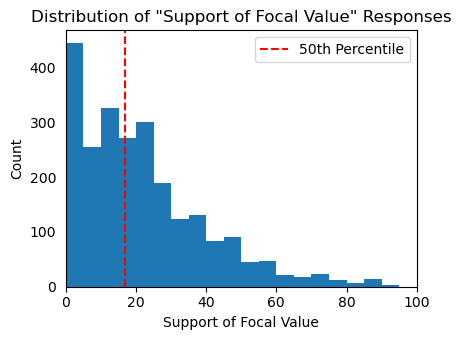

In [12]:
fig, ax = plt.subplots(figsize=(4.5, 3.5))
ax.hist(survey["support.of.focal.value"], bins=list(range(0, 100, 5)))
ax.set_xlabel("Support of Focal Value")
ax.set_ylabel("Count")
ax.set_title('Distribution of "Support of Focal Value" Responses')
ax.set_xlim(0, 100)
ax.axvline(
    survey["support.of.focal.value"].median(),
    color="r",
    linestyle="--",
    label="50th Percentile",
)
ax.tick_params(left=False)
plt.tight_layout()
plt.legend()
plt.show()

Looking at the distribution of responses, its clear that the 0.00 values are not anomalies: there's a clear trend towards low numbers, with >50% of responses under 20.00.

If the survey specifically stated that support involved committing time and money, my best guess is that some respondents are treating the question as aspirational. E.X. id 1172 supports cancer research, but reports they are not currently contributing money or time to their value. It also makes sense that a respondent would take the question to refer to money, specifically, given that the survey is being administered by a credit union. A respondent taking the question that way would be more likely to report 0.00. E.X. id 3927's support for law enforcement is unlikely to be financial in nature because law enforcement in the United States is pubically funded. 

Given the context of the survey, it does not seem resonable to remove or impute the responses with 0.00.

In [13]:
# Investigating ages:
survey.loc[survey["age"] < survey["account.age"], ["id", "age", "account.age"]]

,id,age,account.age
156,633,18,18.090
389,999,30,30.282
730,2376,20,20.696
1440,5588,35,35.907
1468,5852,21,21.222
1553,6277,31,31.164
1778,8951,25,25.474
1858,10532,22,22.197
2234,17906,18,18.762
2250,18005,18,18.337


In all 10 cases where the account age is greater than the respondent age, the discrepency is explained by the data type difference. E.X. A respondent who had an account opened for them when they were born (so-called "newborn savings accounts") and who turned 18 a few months ago will have an account age greater than their reported age.

### 1. Calculate the *Progressivism* Measure
The original survey included the *Moral Foundations Questionnaire* and a summary measure of **progressivism**.  
You’ll recreate it from the five foundation scores:

`harm`, `fair`, `in.group`, `authority`, `purity`

> Hint: Your reading tells you about the `progressivism` calculation. It's the average of the `harm` and `fair` columns minus the average of the other three Moral Foundations Theory dimensions (`purity`, `in.group`, `authority`).

In [14]:
# Calculating progressivism:
survey["progressivism"] = ((survey["harm"] + survey["fair"]) / 2) - (
    (survey["purity"] + survey["in.group"] + survey["authority"]) / 3
)
survey.loc[
    :, ["id", "harm", "fair", "purity", "in.group", "authority", "progressivism"]
].sample(4, random_state=42)

,id,harm,fair,purity,in.group,authority,progressivism
479,1150,4.25,4.25,1.75,3.25,3.75,1.333333
1010,3927,1.75,2.00,3.25,4.50,4.00,-2.041667
2197,17701,4.00,3.75,3.25,3.75,1.75,0.958333
2274,18295,4.50,4.00,3.75,3.50,3.75,0.583333


### 2. Bootstrap the Mean Progressivism by Region
Use **bootstrapping** to estimate the mean and 95% confidence interval of `progressivism` for each `region`.

- Draw at least 1,000 bootstrap samples.  
- Plot a histogram of bootstrap means for one region.  
- Create a summary table or chart showing each region’s estimated mean and CI. Use `quantile` on your bootstrap replicates to calculate a 95% confidence interval.

In [15]:
# Creating a metro column:
survey["metro"] = 0
survey.loc[
    (survey["region"] == "W WA Metro") | (survey["region"] == "Thurston"), "metro"
] = 1
survey.loc[:, ["region", "metro"]].sample(4, random_state=96)

,region,metro
2401,W WA Metro,1
363,W WA Metro,1
2016,W WA Non Metro,0
1779,Thurston,1


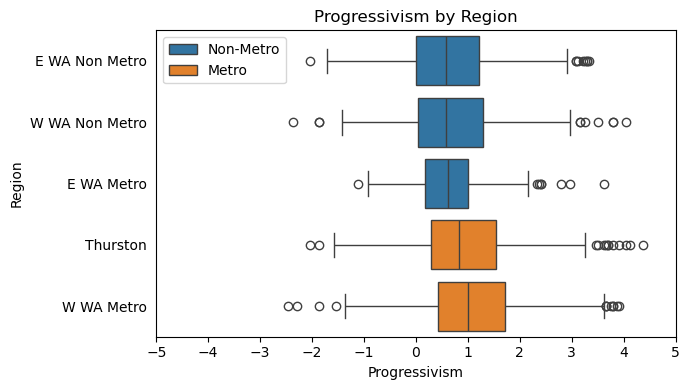

In [16]:
# Investigating progressivism by region
region_order = list(
    survey.groupby("region")["progressivism"].median().sort_values().index
)
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(
    data=survey, x="progressivism", y="region", order=region_order, hue="metro", ax=ax
)
ax.set_xlabel("Progressivism")
ax.set_ylabel("Region")
ax.set_xlim(-5, 5)
ax.set_xticks(range(-5, 6))
ax.tick_params(left=False)
ax.set_title("Progressivism by Region")
handles, labels = (
    ax.get_legend_handles_labels()
)  # Renaming the legend, courtesy of Claude
ax.legend(handles, ["Non-Metro", "Metro"], loc="upper left")
plt.tight_layout()
plt.show()

On initial analysis (here sorted by median progressivism), the metro regions are more progressive than the non-metro regions.

In [17]:
# Investigating Mean Progressivism by Region
mean_prog_by_region = pd.DataFrame(
    survey.groupby("region")["progressivism"].mean()
).rename(columns={"progressivism": "mean_progressivism"})
mean_prog_by_region.sort_values(by="mean_progressivism", ascending=True)

,mean_progressivism
region,
E WA Non Metro,0.632672
E WA Metro,0.637891
W WA Non Metro,0.719505
Thurston,0.961379
W WA Metro,1.101912


##### Creating the sampling distribution with bootstrapping

My chosen statistic (parameter of interest) is mean progressivism.

First I'll calculate the confidence interval for the full sample, and then I'll calculate the mean progressivism per region.

In [18]:
# Calculating the confidence interval for the full sample
replicates = []

for _ in range(1_000):
    replicates.append(survey.sample(frac=1, replace=True)["progressivism"].mean())

In [19]:
overall_percentiles = pd.Series(replicates, name="mean_progressivism").quantile(
    [0.025, 0.25, 0.5, 0.75, 0.975]
)
print(f"Overall observed mean progressivism: {survey['progressivism'].mean():.4f}")
print(
    f"Confidence interval (2.5 percentile to 97.5 percentile): {overall_percentiles[0.025]:.4f} - {overall_percentiles[0.975]:.4f}"
)
print(
    f"I estimate with 95% confidence that the average progressivism of WSECU members is between {overall_percentiles[0.025]:.2f} and {overall_percentiles[0.975]:.2f}."
)

Overall observed mean progressivism: 0.9205
Confidence interval (2.5 percentile to 97.5 percentile): 0.8841 - 0.9597
I estimate with 95% confidence that the average progressivism of WSECU members is between 0.88 and 0.96.


In [20]:
# Calculating the mean progressivism and confidence interval per region
n_sim = 3_000
distribution_dict = {}
mean_prog_by_region["two_point_five_percentile"] = pd.NA
mean_prog_by_region["ninety_seven_point_five_percentile"] = pd.NA

for r in survey["region"].unique():
    print(f"Creating the sampling distribution for {r}...")

    replicates = []

    for _ in range(n_sim):
        replicates.append(
            survey.loc[survey["region"] == r]
            .sample(frac=1, replace=True)["progressivism"]
            .mean()
        )

    distribution_dict[r] = replicates
    mean_prog_by_region.loc[r, "two_point_five_percentile"] = np.quantile(
        replicates, 0.025
    )
    mean_prog_by_region.loc[r, "ninety_seven_point_five_percentile"] = np.quantile(
        replicates, 0.975
    )

Creating the sampling distribution for Thurston...
Creating the sampling distribution for W WA Metro...
Creating the sampling distribution for W WA Non Metro...
Creating the sampling distribution for E WA Non Metro...
Creating the sampling distribution for E WA Metro...


In [21]:
mean_prog_by_region.sort_values(by="mean_progressivism")

,mean_progressivism,two_point_five_percentile,ninety_seven_point_five_percentile
region,,,
E WA Non Metro,0.632672,0.526852,0.738896
E WA Metro,0.637891,0.536585,0.745862
W WA Non Metro,0.719505,0.603412,0.841486
Thurston,0.961379,0.891951,1.032532
W WA Metro,1.101912,1.039997,1.1632


In [22]:
# Chart of estimated mean progressivism and confidence intervals, by region
for r, data in mean_prog_by_region.sort_values(by="mean_progressivism").iterrows():
    print(
        f"{r}:\tMean Progressivism {data['mean_progressivism']:.2f} ({data['two_point_five_percentile']:.2f} - {data['ninety_seven_point_five_percentile']:.2f})"
    )

E WA Non Metro:	Mean Progressivism 0.63 (0.53 - 0.74)
E WA Metro:	Mean Progressivism 0.64 (0.54 - 0.75)
W WA Non Metro:	Mean Progressivism 0.72 (0.60 - 0.84)
Thurston:	Mean Progressivism 0.96 (0.89 - 1.03)
W WA Metro:	Mean Progressivism 1.10 (1.04 - 1.16)


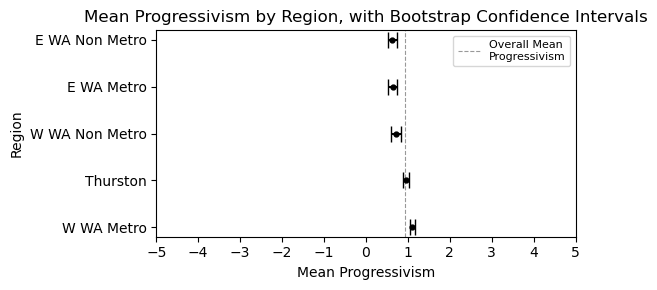

In [23]:
# Plotting these regional mean progressivisms
# Adapted from the Restaurant mean rating example, plus a lot of Claude

for_plot = mean_prog_by_region.sort_values(by="mean_progressivism", ascending=False)

xerr = [
    for_plot["mean_progressivism"]
    - for_plot["two_point_five_percentile"],  # left error
    for_plot["ninety_seven_point_five_percentile"]
    - for_plot["mean_progressivism"],  # right error
]

fig, ax = plt.subplots(figsize=(6, 3))

ax.errorbar(
    x=for_plot["mean_progressivism"],
    y=for_plot.index,
    xerr=xerr,
    fmt="o",
    capsize=6,
    color="k",
    linewidth=1.5,
    markersize=3.5,
)
ax.axvline(
    survey["progressivism"].mean(),
    color="k",
    linestyle="--",
    linewidth=0.8,
    alpha=0.4,
    label="Overall Mean\nProgressivism",
)

ax.set_xlabel("Mean Progressivism")
ax.set_ylabel("Region")
ax.set_title("Mean Progressivism by Region, with Bootstrap Confidence Intervals")
ax.set_xlim(-5.0, 5.0)
ax.set_xticks([-5, -4, -3, -2, -1, 0, 1, 2, 3, 4, 5])

plt.legend(fontsize=8)
plt.tight_layout()
plt.show()

This plot shows that the confidence is interval is wider for the non-metro regions with smaller sample sizes.

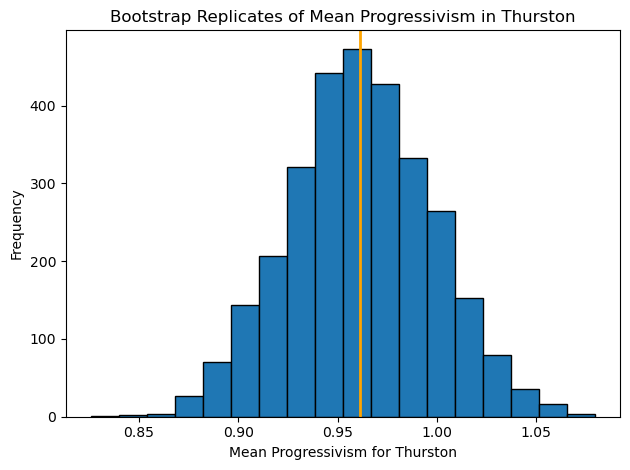

In [24]:
def plot_sampling_distribution(df, replicates_data, region):
    plt.hist(replicates_data[region], bins=18, edgecolor="black")
    plt.axvline(
        df.loc[region, "mean_progressivism"], color="orange", linestyle="-", linewidth=2
    )
    plt.xlabel(f"Mean Progressivism for {region}")
    plt.ylabel("Frequency")
    plt.title(f"Bootstrap Replicates of Mean Progressivism in {region}")
    plt.tight_layout()
    plt.show()


# Plotting a histogram of bootstrap means for one region
plot_sampling_distribution(mean_prog_by_region, distribution_dict, "Thurston")

### 3. Bootstrap the Fraction Supporting Education
Estimate the **fraction of members** in each region whose `main.focal.value == "Education"`.  
Use bootstrapping to generate a confidence interval for this proportion.

In [25]:
# Exploring the 11 focal values, with a highlight on Education:
print(
    f"Percentage of survey respondents who chose education as their main focal value: {(survey["main.focal.value"].value_counts(normalize=True)['Education'])*100:.2f}%"
)

Percentage of survey respondents who chose education as their main focal value: 16.85%


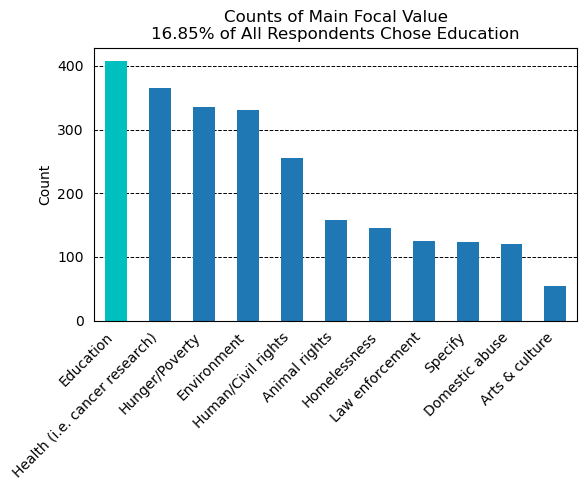

In [26]:
fig, ax = plt.subplots(figsize=(6, 5))

survey["main.focal.value"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Counts of Main Focal Value\n16.85% of All Respondents Chose Education")
ax.set_xlabel("")
ax.set_ylabel("Count")
ax.set_yticks([0, 100, 200, 300, 400])
ax.tick_params(left=False, bottom=False)
ax.yaxis.grid(True, linestyle="--", linewidth=0.7, color="k", alpha=1)
ax.set_axisbelow(True)  # Claude taught me this one
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")

# Recoloring one bar, courtesy of Claude
bars = ax.patches
max_bar = max(bars, key=lambda b: b.get_height())
max_bar.set_facecolor("c")

plt.tight_layout()
plt.show()

In [27]:
prop_value_edu_by_region = pd.DataFrame(
    survey.groupby("region")["main.focal.value"].value_counts(normalize=True)[
        :, "Education"
    ]
).rename(columns={"proportion": "prop_value_edu"})
prop_value_edu_by_region.sort_values("prop_value_edu")

,prop_value_edu
region,
E WA Metro,0.143646
W WA Non Metro,0.144928
Thurston,0.158621
W WA Metro,0.170996
E WA Non Metro,0.219048


In [28]:
# Calculating the mean progressivism and confidence interval per region
n_sim = 1_000
prop_value_edu_by_region["two_point_five_percentile"] = pd.NA
prop_value_edu_by_region["ninety_seven_point_five_percentile"] = pd.NA

for r in survey["region"].unique():
    print(f"Creating the sampling distribution for {r}...")

    replicates = []

    for _ in range(n_sim):
        replicates.append(
            survey.loc[survey["region"] == r, "main.focal.value"]
            .sample(frac=1, replace=True)
            .value_counts(normalize=True)["Education"]
        )

    prop_value_edu_by_region.loc[r, "two_point_five_percentile"] = np.quantile(
        replicates, 0.025
    )
    prop_value_edu_by_region.loc[r, "ninety_seven_point_five_percentile"] = np.quantile(
        replicates, 0.975
    )

Creating the sampling distribution for Thurston...
Creating the sampling distribution for W WA Metro...
Creating the sampling distribution for W WA Non Metro...
Creating the sampling distribution for E WA Non Metro...
Creating the sampling distribution for E WA Metro...


In [29]:
# Chart of estimated proportion of support for education and confidence intervals, by region
for r, data in prop_value_edu_by_region.sort_values(by="prop_value_edu").iterrows():
    print(
        f"{r}:\tPercent supporting education: {data['prop_value_edu']*100:.2f}% ({data['two_point_five_percentile']*100:.2f}% - {data['ninety_seven_point_five_percentile']*100:.2f}%)"
    )

E WA Metro:	Percent supporting education: 14.36% (9.39% - 19.89%)
W WA Non Metro:	Percent supporting education: 14.49% (10.51% - 18.48%)
Thurston:	Percent supporting education: 15.86% (13.38% - 18.76%)
W WA Metro:	Percent supporting education: 17.10% (14.72% - 19.59%)
E WA Non Metro:	Percent supporting education: 21.90% (17.46% - 26.67%)


The confidence intervals for the E WA Metro region and the E WA Non Metro region overlap, which invites further investigation into the apparent difference in support for education.

### 4. Permutation Test: Metro vs. Non-Metro
Group the regions into two groups:  
- **Group 1:** W WA Metro and Thurston  
- **Group 2:** W WA Non-metro, E WA Non-metro, and E WA Metro

Perform a **permutation test** to determine whether the proportion supporting Education differs between these two groups.

In [30]:
# Exploring the proportion of respondents who support education for the metro and non-metro regions:
survey.groupby("metro")["main.focal.value"].value_counts(normalize=True)[
    :, "Education"
].to_frame().rename(
    index={0: "non-metro", 1: "metro"}, columns={"proportion": "prop_support_edu"}
)

,prop_support_edu
metro,
non-metro,0.174870
metro,0.165555


It looks like the non-metro regions support education (that is, choose education as the main focal value on the survey) at a greater proportion than the metro regions do.

My null hypothesis is that region (metro or non-metro) has no effect on support for education.

My alternative hypothesis is that non-metro region respondents have a higher percentage support for education than metro region respondents. 

My test statistic is the difference between the proportion of non-metro respondents who support education and the proportion of metro respondents who support education.

In [31]:
def prop_support_edu_diff(df: pd.DataFrame):
    return (
        df.loc[df["metro"] == 0, "main.focal.value"].value_counts(normalize=True)[
            "Education"
        ]
        - df.loc[df["metro"] == 1, "main.focal.value"].value_counts(normalize=True)[
            "Education"
        ]
    )


observed_value = prop_support_edu_diff(survey)
print(
    f"Observed difference between non-metro support for education and metro support for education: {observed_value*100:.2f}%"
)

Observed difference between non-metro support for education and metro support for education: 0.93%


In [32]:
replicates = [observed_value]
n_sim = 5_000
sim_survey = survey.copy()

for _ in range(n_sim - 1):
    sim_survey["metro"] = (
        sim_survey["metro"].sample(frac=1, replace=False).reset_index(drop=True)
    )
    replicates.append(prop_support_edu_diff(sim_survey))

p-value: 0.2954


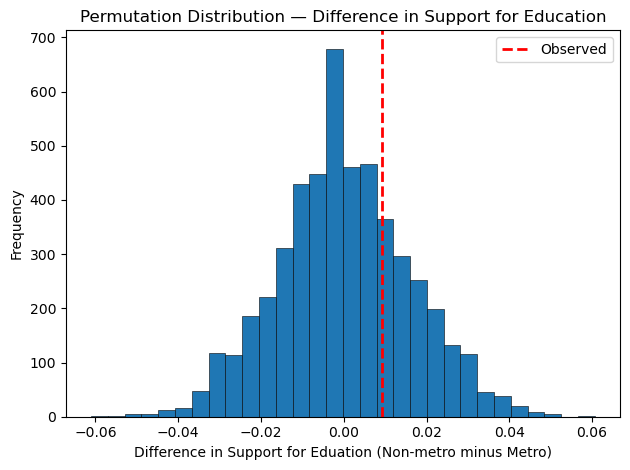

In [33]:
p_value = np.mean(pd.Series(replicates) >= observed_value)
print(f"p-value: {p_value:.4f}")

plt.hist(replicates, bins=30, edgecolor="black", linewidth=0.4)
plt.axvline(observed_value, color="red", linestyle="--", linewidth=2, label="Observed")
plt.xlabel("Difference in Support for Eduation (Non-metro minus Metro)")
plt.ylabel("Frequency")
plt.title("Permutation Distribution — Difference in Support for Education")
plt.legend()
plt.tight_layout()
plt.show()

There's a ~30% chance that an observed difference of 0.93% or greater in support for education between non-metro and metro regions is due to random chance, under the null hypothesis.

Because this is so likely, we cannot reject the null hypothesis.

| Element from OOT | In your example |
|:--|:--|
| **1. Data** | The proportion of survey respondents who chose "Education" as their main focal value. |
| **2. Test statistic** | The difference between the proportion of non-metro respondents who support education and the metro respondents who support education. |
| **3. Observed value or effect** | 0.93% more support from non-metro respondents. |
| **4. Null hypothesis** | Region (metro or non-metro) has no effect on the proportion of respondents who support education. |
| **5. How you simulate data under the null** | Permute the `metro` column many times. |
| **6. Description of the reference distribution** | The permutation distribution shows the distribution of differences between the proportion of non-metro respondents who support education and the metro respondents who support education, if the null hypothesis is true. |
| **7. p-value from comparing observed to simulated** | 0.3068, or 30.68%. |

### 5. Reflect

- How long did the assignment take you?

5-6 hours.

- What was the hardest part of doing it?

Analyzing the results is quite difficult, because it is so easy to leap to conclusions or use the wrong language. I'm thinking in particular of how careful I need to be when describing what a p-value means. Another example: above, I use the phrase "support education" to refer to a survey respondent chosing "Education" as a main focal value over other focal values. I don't know if that assumption (that choosing education on the survey is equivalent to supporting education) is justified. I suppose in a professional context I would need to find an expert in survey design to help me determine if that kind of assumption is appropriate. It's at the end of an assignment, when I'm writing the reflection, that I most feel the weight of all the assumptions I've had to make just to arrive at the conclusions I did.

Every plot is difficult to do.

- Do you have any unresolved questions?

Confidence intervals certainly seem important, but do they enable any analysis by themselves? For the mean restaurant ratings, for example, the addition of confidence intervals makes it clear there's some non-zero chance that Estelle is rated higher than Gus Gus, or that Local Rumor is rated higher than Myriel. But to actually determine the significance of the overlap between the CIs, I would need to perform additional hypothesis testing (permutation tests, etc). To put it another way, ought I realize something about the data, just by looking at a point estimate and its confidence interval?

---